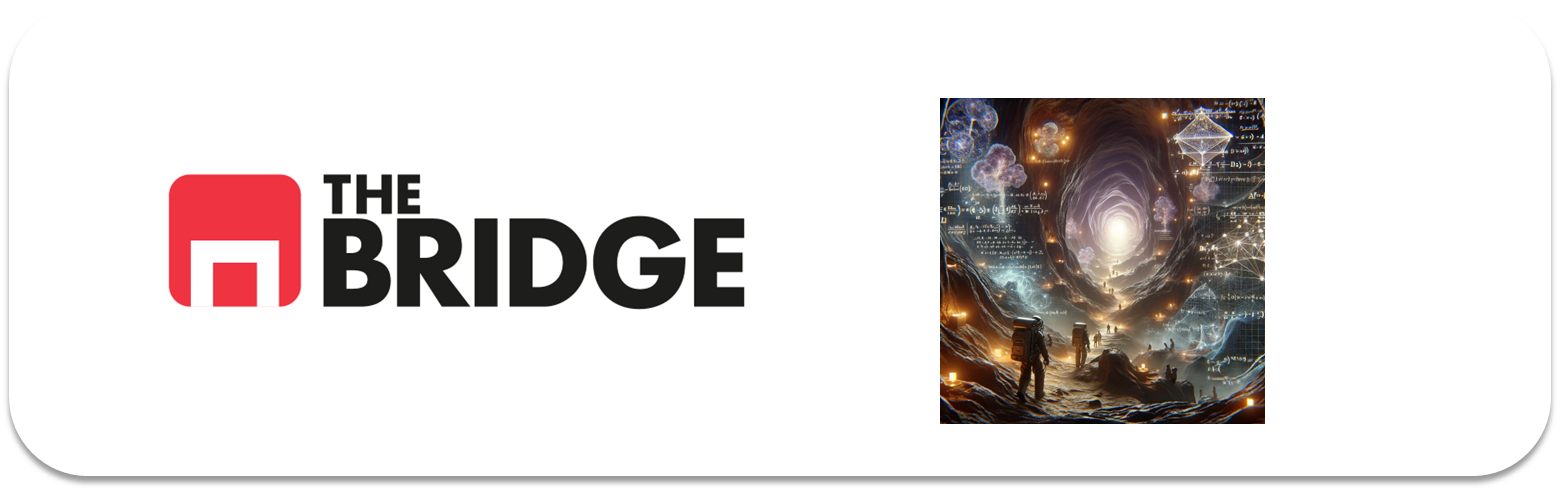

## PRACTICA OBLIGATORIA: **Introducción Deep Learning**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import bootcampviztools as bvt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             classification_report, confusion_matrix)

import warnings
warnings.filterwarnings("ignore")

### Descripción y objetivo

El objetivo de la práctica es crear un modelo DL y compararlo con un modelo Random Forest para el dataset de titanic los dos con el mismo objetivo, predecir la supervivencia de un pasajero.  Se pide:  
1. Desarrollar el proceso de ML hasta crear los dos modelos DL y Random Forest. El primero debe tener una topología MLP (es decir una red densa) con un máximo de 3 capas ocultas y debes emplear sklearn para crearlo. No es necesario hacer una análisis/seleccion exahustivo. Escoge una métrica acorde al tipo de target del problema. 

2. Ambos modelos deben tener sus hiperparámetros optimizados, mediante GridSearch. Para ello: utiliza el grid de parámetros que creas conveniente para Random Forest y para el modelo DL, utiliza un grid con los hiperparámetros siguientes:'hidden_layer_sizes','activation', 'solver','alpha' y 'learning_rate'. Para los rangos del grid del modelo de DL guíate por lo visto en el workout y por los posibles valores que se indican en la [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier). Prueba por lo menos una topología con una sola capa oculta y otra con más de una capa oculta.   
NOTA: Incluye los valores por defecto de los hiperparámetros escogidos en cada caso dentro del grid de hiperparámetros. 
  

3. Compara los modelos respecto a sus métricas medias de accuracy, precision, recall y tiempos de entrenamiento (para ello tendrás que realizar un entrenamiento a parte del mejor modelo obtenido en la optimización de hiperparámetros) y decide cuál te quedarías argumentándolo.    

4. Para el mejor modelo DL obtenido, muestra su clasification report, y la matriz de confusión comentando el resultado.


In [2]:
# Cargamos el dataset del Titanic
df = pd.read_csv("./data/titanic.csv")

print("Dimensiones:", df.shape)
print("\nNulos por columna:")
print(df.isna().sum())
df.head()

Dimensiones: (891, 15)

Nulos por columna:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Target y limpieza**

El target es `survived` (0 = no sobrevivió, 1 = sobrevivió). Antes de nada, hay que quitar columnas problemáticas:

- `alive` es literalmente el target en texto (`yes`/`no`) genera data leakage, se elimina.
- `class`, `embark_town` y `adult_male`/`who` son redundantes con `pclass`, `embarked` y `sex`/`age`.
- `deck` tiene 77% de nulos.

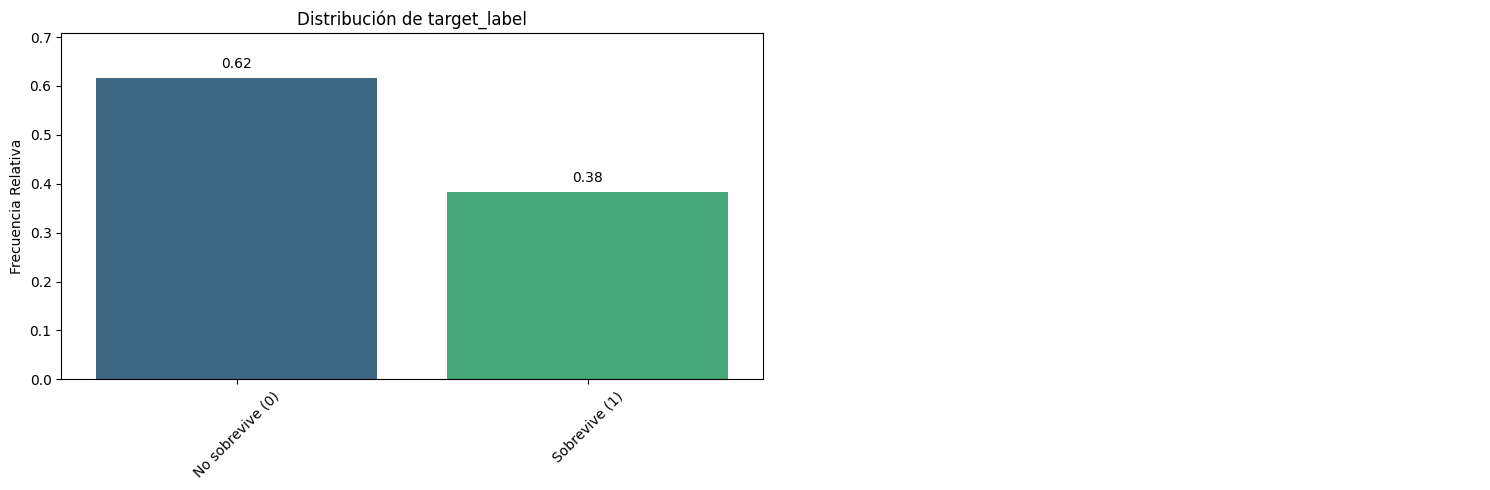

{0: 0.616, 1: 0.384}


In [3]:
df["target_label"] = df["survived"].map({0: "No sobrevive (0)", 1: "Sobrevive (1)"})
bvt.pinta_distribucion_categoricas(df, ["target_label"], relativa=True, mostrar_valores=True)

print(df["survived"].value_counts(normalize=True).round(3).to_dict())

In [4]:
# Eliminamos fugas, redundantes y la columna con demasiados nulos
columnas_fuera = ["alive", "class", "embark_town", "adult_male", "who", "deck"]
df = df.drop(columns=columnas_fuera)

print("Columnas restantes:", df.columns.tolist())

Columnas restantes: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone', 'target_label']


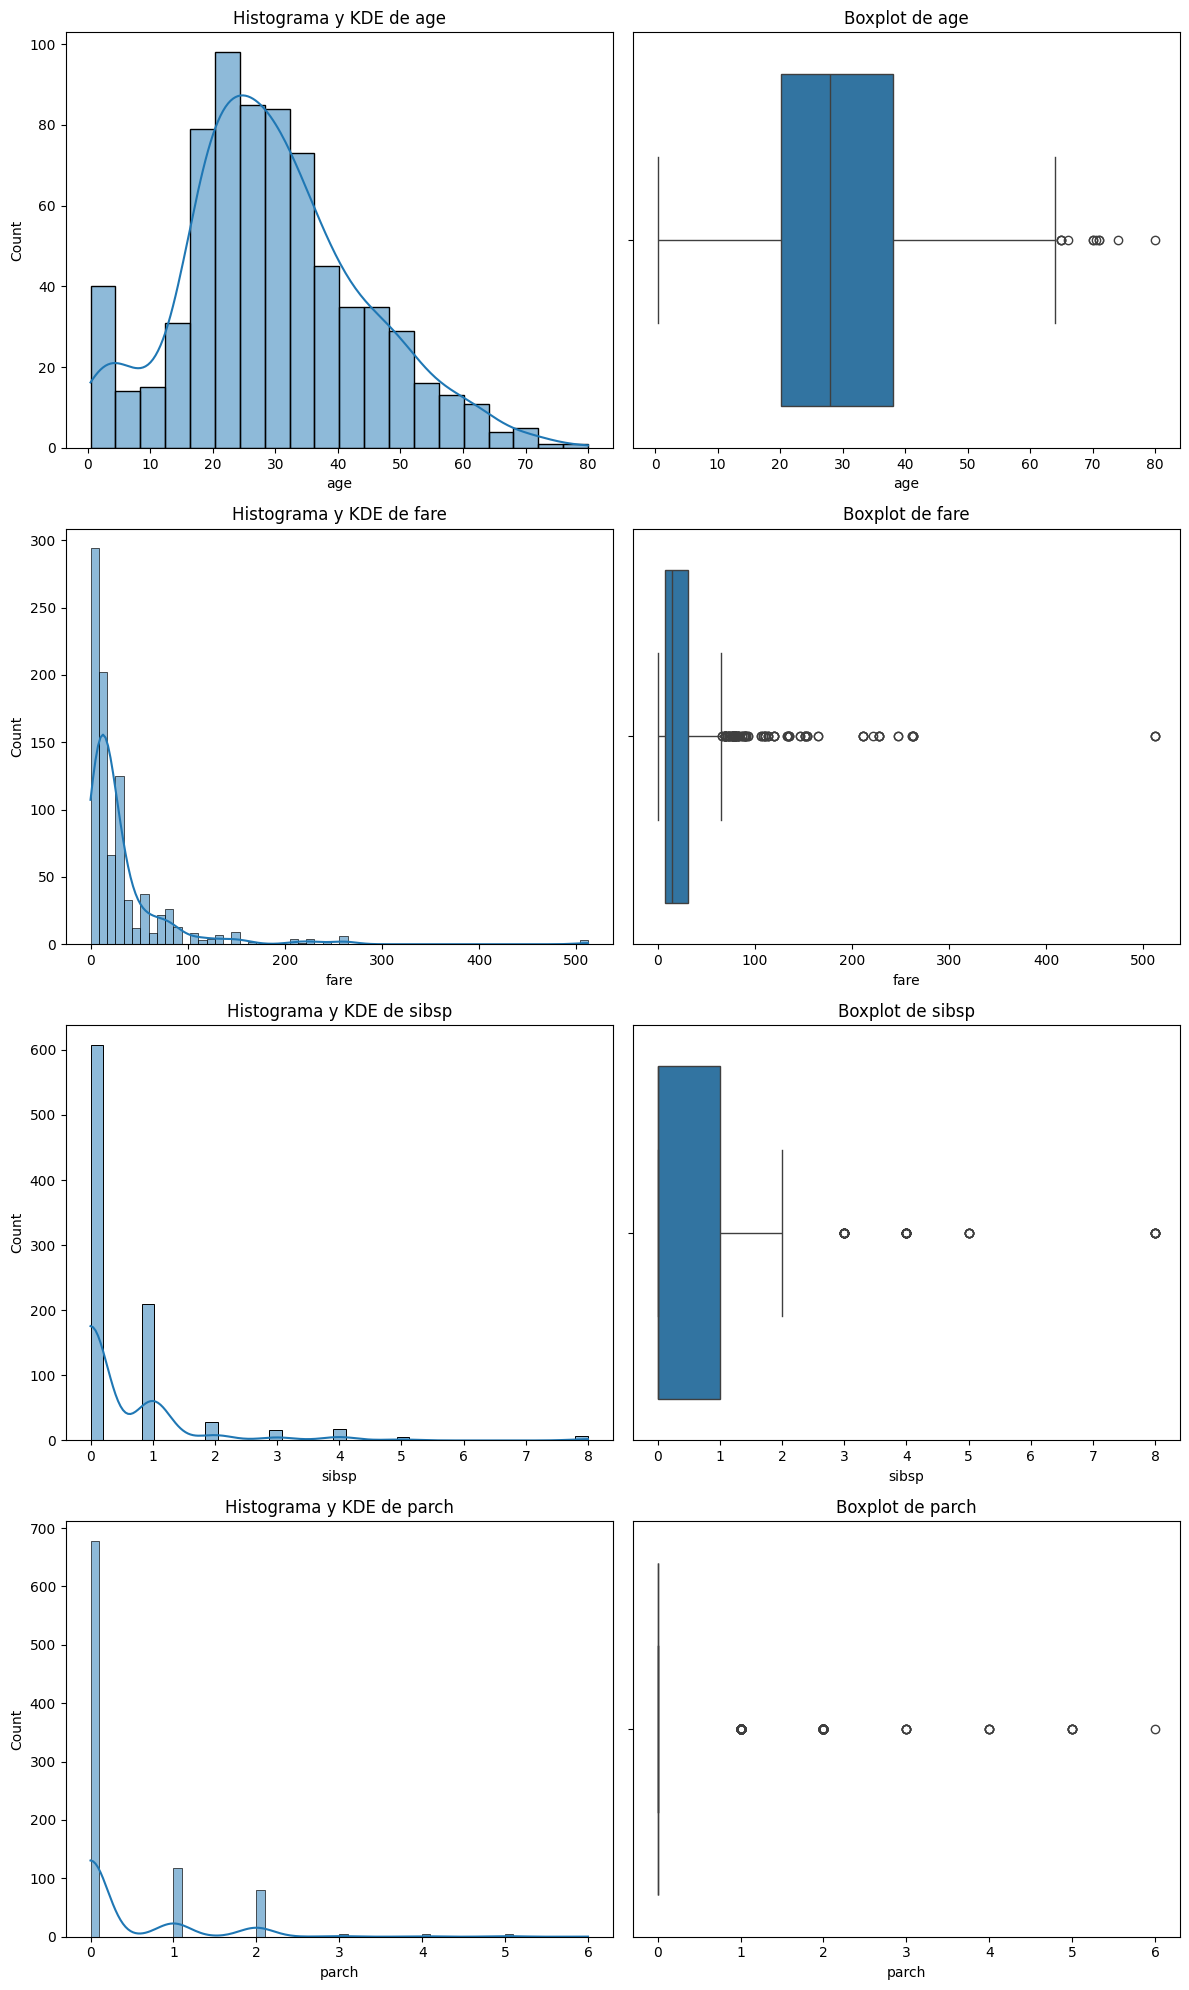

In [5]:
# Definimos numericas y categoricas para el EDA
num_cols = ["age", "fare", "sibsp", "parch"]
cat_cols = ["pclass", "sex", "embarked", "alone"]

# Distribucion de las numericas: histograma + boxplot
bvt.plot_combined_graphs(df, num_cols)

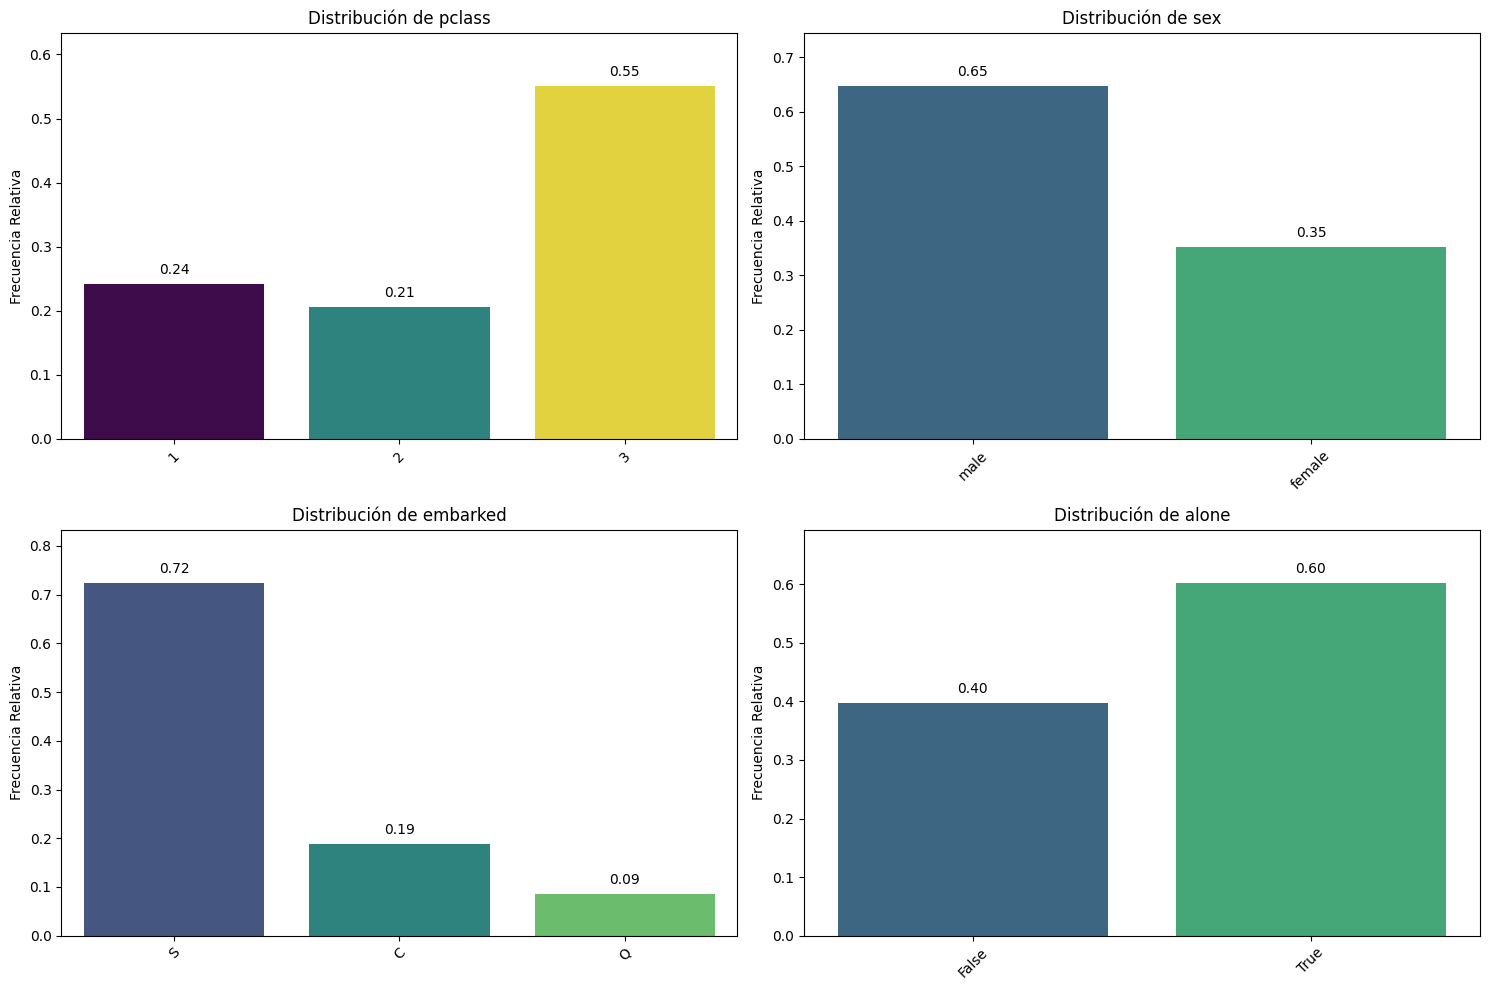

In [6]:
# Reparto de las categoricas
bvt.pinta_distribucion_categoricas(df, cat_cols, relativa=True, mostrar_valores=True)

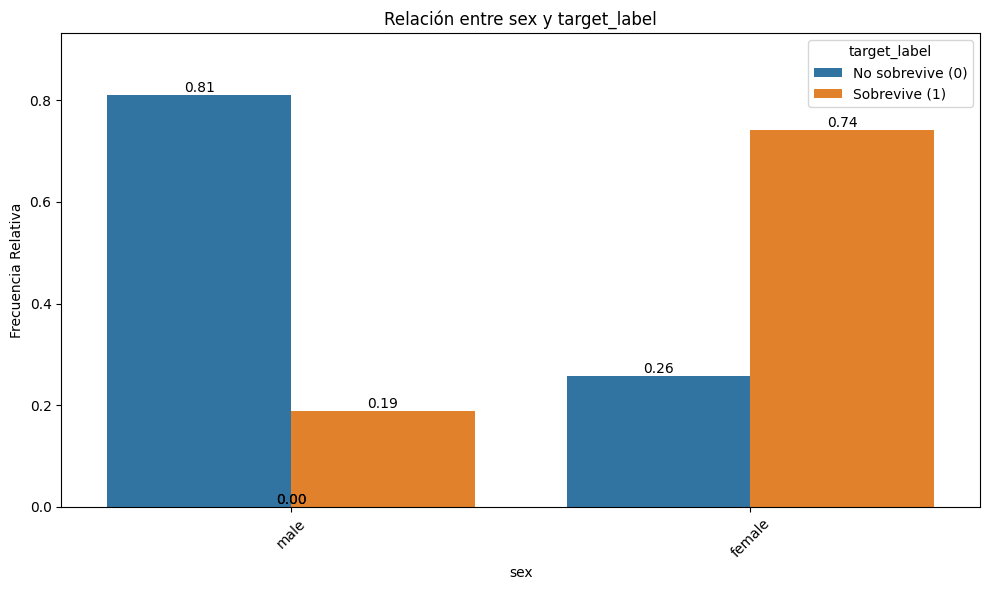

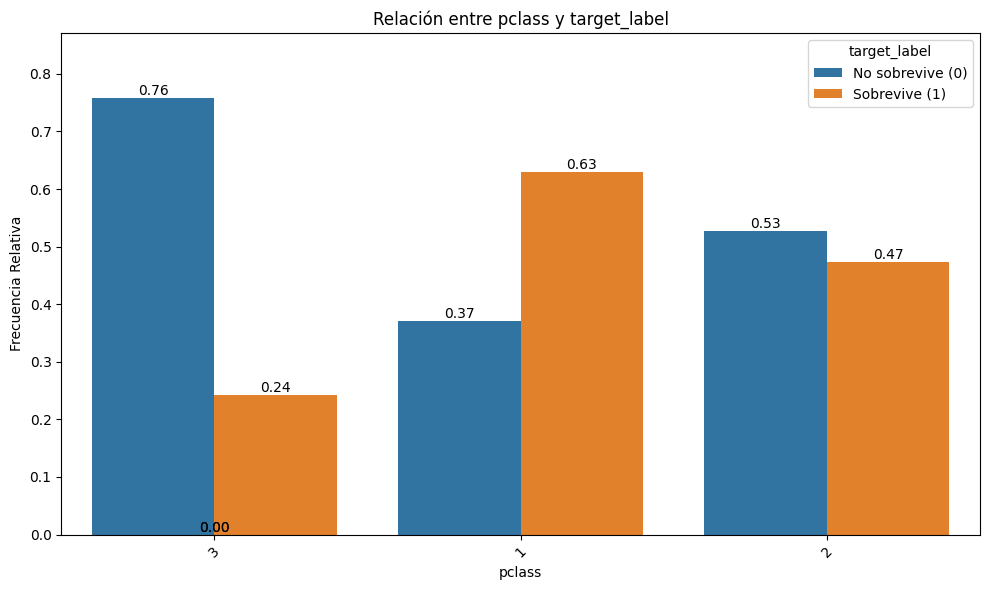

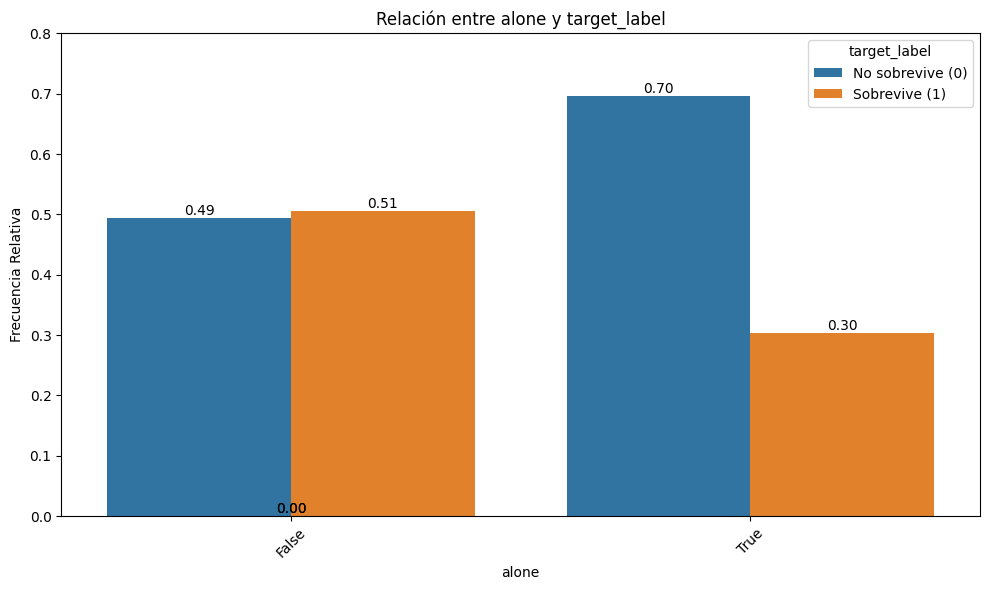

In [7]:
# Relacion de las categoricas con la supervivencia (frecuencia relativa)
for col in ["sex", "pclass", "alone"]:
    bvt.plot_categorical_relationship(df, col, "target_label",
                                      relative_freq=True, show_values=True)

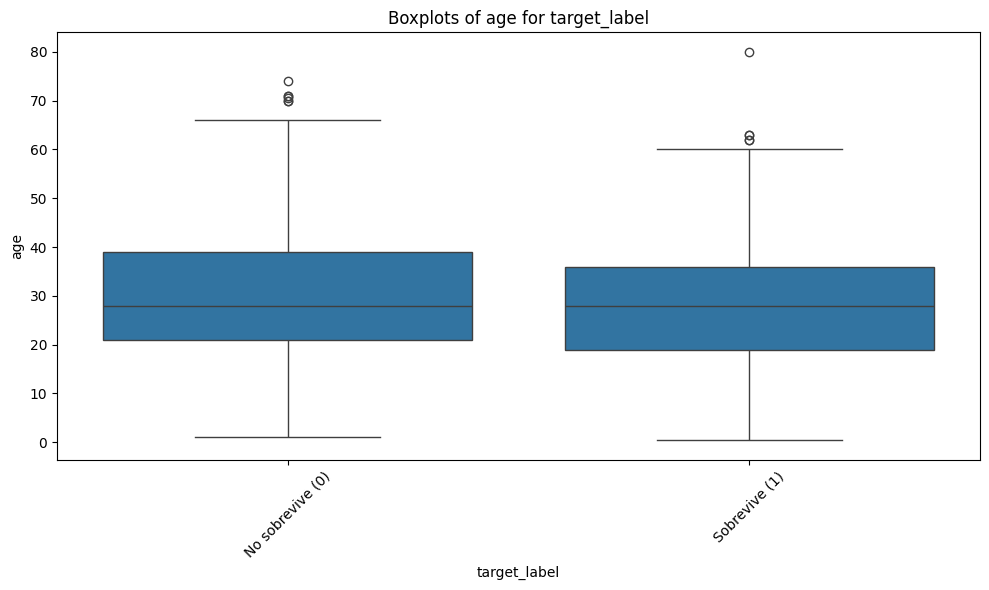

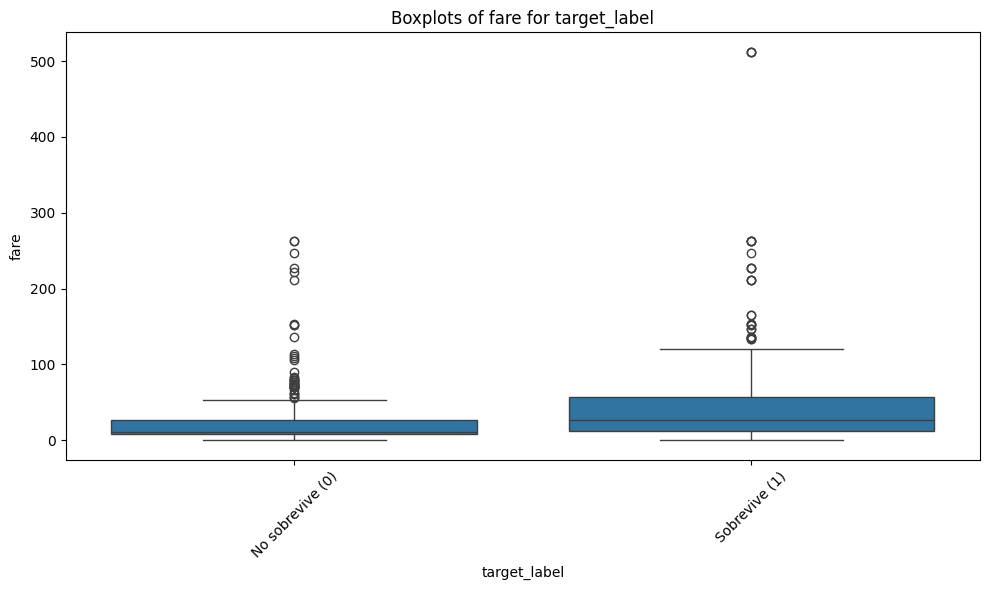

In [8]:
# Relacion de las numericas con la supervivencia (boxplot agrupado)
for col in ["age", "fare"]:
    bvt.plot_grouped_boxplots(df, "target_label", col)

**Preprocesado**

Imputamos los pocos nulos que quedan (`age` con la mediana, `embarked` con la moda), codificamos las categóricas y dejamos `alone` como 0/1. Escalamos para el DL; el Random Forest no lo necesita pero lo aplicamos por igual.

In [9]:
# Imputamos nulos restantes
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Codificamos categoricas (one-hot) y pasamos alone a 0/1
df_model = pd.get_dummies(df.drop(columns=["target_label"]),
                          columns=["sex", "embarked"], drop_first=True)
df_model["alone"] = df_model["alone"].astype(int)

features = [c for c in df_model.columns if c != "survived"]
print("Features finales:", features)

Features finales: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'sex_male', 'embarked_Q', 'embarked_S']


In [10]:
# Split estratificado (target algo desbalanceado 62/38) y escalado
X = df_model[features]
y = df_model["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (712, 9)  Test: (179, 9)


Como el target es binario y no demasiado desbalanceado, usamos **accuracy** como métrica principal para GridSearch, y luego comparamos también precision y recall. Usamos validación cruzada estratificada de 5 folds.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

**Modelo 1 — Red neuronal (DL con sklearn)**

Topología DL con máximo 3 capas ocultas. El grid incluye los hiperparámetros pedidos (`hidden_layer_sizes`, `activation`, `solver`, `alpha`, `learning_rate`) con sus valores por defecto (relu, adam, alpha=0.0001, learning_rate=constant). Probamos una topología de 1 capa y otras de 2 y 3 capas.

In [13]:
mlp_grid = {
    "hidden_layer_sizes": [(100,), (50, 50), (64, 32, 16)],  # 1, 2 y 3 capas
    "activation": ["relu", "tanh"],                          # default: relu
    "solver": ["adam"],                                      # default: adam
    "alpha": [0.0001, 0.001],                                # default: 0.0001
    "learning_rate": ["constant", "adaptive"],               # default: constant
}

t0 = time.time()
grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42),
    mlp_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
grid_mlp.fit(X_train_s, y_train)
tiempo_grid_mlp = time.time() - t0

print("Mejores hiperparametros MLP:", grid_mlp.best_params_)
print("Mejor accuracy CV:", round(grid_mlp.best_score_, 3))
print("Tiempo del GridSearch MLP:", round(tiempo_grid_mlp, 1), "s")

Mejores hiperparametros MLP: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}
Mejor accuracy CV: 0.823
Tiempo del GridSearch MLP: 21.6 s


**5. Modelo 2 — Random Forest**

In [14]:
# Grid del Random Forest (incluye defaults: n_estimators=100, max_depth=None, min_samples_leaf=1)
rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 8],
    "min_samples_leaf": [1, 5],
}

t0 = time.time()
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
# El RF no necesita escalado, usamos X_train tal cual
grid_rf.fit(X_train, y_train)
tiempo_grid_rf = time.time() - t0

print("Mejores hiperparametros RF:", grid_rf.best_params_)
print("Mejor accuracy CV:", round(grid_rf.best_score_, 3))
print("Tiempo del GridSearch RF:", round(tiempo_grid_rf, 1), "s")

Mejores hiperparametros RF: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 200}
Mejor accuracy CV: 0.822
Tiempo del GridSearch RF: 1.7 s


**Comparación de los dos modelos**

Entrenamos por separado el mejor MLP y el mejor RF para **medir el tiempo de entrenamiento** de cada uno, y comparamos accuracy, precision y recall en test.

In [15]:
mlp_best = MLPClassifier(max_iter=500, random_state=42, **grid_mlp.best_params_)
rf_best = RandomForestClassifier(random_state=42, **grid_rf.best_params_)

t0 = time.time(); mlp_best.fit(X_train_s, y_train); tiempo_fit_mlp = time.time() - t0
t0 = time.time(); rf_best.fit(X_train, y_train); tiempo_fit_rf = time.time() - t0

# Predicciones
pred_mlp = mlp_best.predict(X_test_s)
pred_rf = rf_best.predict(X_test)

# Tabla comparativa
comparacion = pd.DataFrame({
    "modelo": ["MLP (red neuronal)", "Random Forest"],
    "accuracy": [accuracy_score(y_test, pred_mlp), accuracy_score(y_test, pred_rf)],
    "precision": [precision_score(y_test, pred_mlp), precision_score(y_test, pred_rf)],
    "recall": [recall_score(y_test, pred_mlp), recall_score(y_test, pred_rf)],
    "tiempo_entren_s": [tiempo_fit_mlp, tiempo_fit_rf],
}).round(3)

comparacion

,modelo,accuracy,precision,recall,tiempo_entren_s
0,MLP (red neuronal),0.777,0.764,0.609,0.617
1,Random Forest,0.804,0.793,0.667,0.184


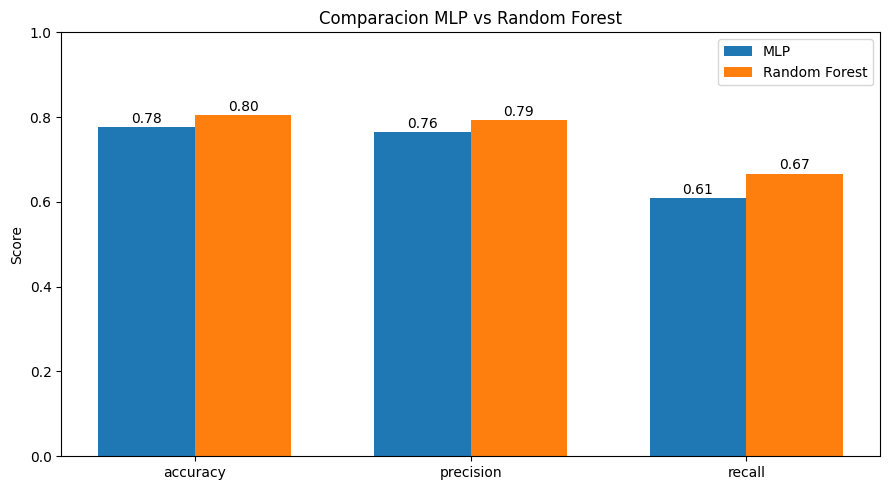

In [16]:
# Lo vemos en un grafico de barras para comparar de un vistazo
metricas = ["accuracy", "precision", "recall"]
x = np.arange(len(metricas))
ancho = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - ancho/2, comparacion.loc[0, metricas], ancho, label="MLP")
plt.bar(x + ancho/2, comparacion.loc[1, metricas], ancho, label="Random Forest")
plt.xticks(x, metricas)
plt.ylabel("Score")
plt.title("Comparacion MLP vs Random Forest")
plt.ylim(0, 1)
plt.legend()
for i, met in enumerate(metricas):
    plt.text(i - ancho/2, comparacion.loc[0, met] + 0.01, f'{comparacion.loc[0, met]:.2f}', ha="center")
    plt.text(i + ancho/2, comparacion.loc[1, met] + 0.01, f'{comparacion.loc[1, met]:.2f}', ha="center")
plt.tight_layout()
plt.show()

**¿Cuál me quedaría?**

Los dos modelos obtienen valores muy parecidos en accuracy (~0.78–0.80). La diferencia está en:

- El Random Forest entrena bastante más rápido, no necesita escalado, y da métricas iguales o algo mejores, además de ser interpretable.

- El MLP tarda más en entrenar y en optimizar (el GridSearch es más lento), y para un dataset pequeño no aporta ventaja.

**Me quedaría con el Random Forest**: mismo rendimiento (o mejor), más rápido, más simple e interpretable. El MLP sería preferible en problemas con muchísimos más datos.

**Análisis del mejor modelo DL (MLP)**

Classification report y matriz de confusión del mejor MLP.

In [17]:
# Classification report del mejor MLP
print("Classification report - MLP\n")
print(classification_report(y_test, pred_mlp, target_names=["No sobrevive", "Sobrevive"]))

Classification report - MLP

              precision    recall  f1-score   support

No sobrevive       0.78      0.88      0.83       110
   Sobrevive       0.76      0.61      0.68        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.75       179
weighted avg       0.78      0.78      0.77       179



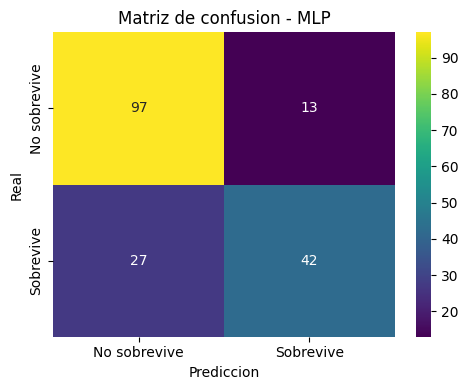

In [18]:
# Matriz de confusion del mejor MLP
cm = confusion_matrix(y_test, pred_mlp)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=["No sobrevive", "Sobrevive"],
            yticklabels=["No sobrevive", "Sobrevive"])
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion - MLP")
plt.tight_layout()
plt.show()

**Comentario:**

El MLP acierta bien a los que no sobreviven (mayor recall en la clase 0), pero se le escapan más supervivientes reales (recall de la clase 1 más bajo). En la matriz de confusión los falsos negativos (supervivientes clasificados como no supervivientes) son el error más frecuente.